# Dance Clubs Data Exploration
Exploring the raw survey responses and the consolidated `clubs.json` knowledge base.

## 1. Load Raw Survey Data

In [3]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('data/Cal Poly Dance Club Responses - Form Responses 1.csv')

# Shorten column names for easier use
df.columns = [
    'timestamp', 'club_name', 'sister_clubs', 'hours_per_week',
    'competes', 'travels', 'performs_downtown', 'culture',
    'dance_style', 'does_covers', 'big_little', 'collects_dues',
    'performance_contract', 'skill_levels', 'performances_per_year',
    'notes', 'contact'
]

df.head()

,timestamp,club_name,sister_clubs,hours_per_week,competes,travels,performs_downtown,culture,dance_style,does_covers,big_little,collects_dues,performance_contract,skill_levels,performances_per_year,notes,contact
0,5/18/2026 23:49:47,Lion Dance Team (LDT),CSA,2.0,No,Yes,Yes,NaN,Chinese,No,No,No,NaN,Beginner,10.0,Lion dance is a nonprofit organization that al...,clngo654@gmail.com
1,5/19/2026 0:04:49,Cal Poly Lion Dance Team,"Cal Poly CSA, TOK",4.0,No,Yes,Yes,Asian,NaN,No,No,No,No,"Beginner, Intermediate, Advanced",NaN,NaN,NaN
2,5/19/2026 0:14:17,Shan Wu Dance Team,CSA (and affiliated),4.0,No,No,No,Chinese,"Chinese traditional, ballet-esque",No,No,No,No,"Beginner, Intermediate, Advanced",4.0,NaN,NaN
3,5/18/2026 18:40:05,SLO Breakers,"K2, UM",4.0,Yes,Yes,No,Not necessarily. Maybe American since it began...,Break Dancing,No,Yes,Yes,No,"Beginner, Intermediate, Advanced",5.0,"We are one of, if not the only, freestyle danc...",(909) 492-6580. Victor Cordero
4,5/19/2026 9:53:12,Trăm Phần Trăm (TPT),NaN,2.0,No,No,NaN,Vietnamese,Traditional mixed with bits of modern?,No,No,Yes,Yes,"Beginner, Intermediate, Advanced",3.0,TPT is under VSA and the amount of practice de...,Hana Huynh (discord username hanavuh) 650-832-...


## 2. Raw Response Counts — How Many Responses Per Club?

In [4]:
# Normalize club names to lowercase/stripped for grouping
df['club_name_norm'] = df['club_name'].str.strip().str.lower()

response_counts = df['club_name_norm'].value_counts()
print(f"Total responses: {len(df)}")
print(f"Unique club name variants: {df['club_name_norm'].nunique()}")
print()
print(response_counts.to_string())

Total responses: 26
Unique club name variants: 20

club_name_norm
merge                                  4
shanwu                                 2
kaja krew                              2
united movement                        2
slo breakers                           1
shan wu dance team                     1
cal poly lion dance team               1
lion dance team (ldt)                  1
pce modern                             1
k2                                     1
pce kasayahan                          1
trăm phần trăm (tpt)                   1
tahitian                               1
cpsalsa                                1
merge contemporary dance club          1
ballroom team                          1
andaaz                                 1
imagen y espiritu ballet folklorico    1
drag club                              1
cal poly andaaz                        1


## 3. Load Consolidated clubs.json

In [5]:
with open('data/clubs.json') as f:
    clubs_data = json.load(f)

clubs = pd.DataFrame(clubs_data['clubs'])

print(f"Clubs in knowledge base: {len(clubs)}")
clubs[['name', 'hours_per_week', 'competes', 'travels', 'performs_downtown',
       'collects_dues', 'big_little_program', 'performances_per_year']]

Clubs in knowledge base: 15


,name,hours_per_week,competes,travels,performs_downtown,collects_dues,big_little_program,performances_per_year
0,Lion Dance Team (LDT),2.0,False,True,True,False,False,10
1,Shan Wu Dance Team,4.0,False,False,False,False,False,5
2,SLO Breakers,4.0,True,True,False,True,True,5
3,TrÄƒm Pháº§n TrÄƒm (TPT),2.0,False,False,None,True,False,3
4,PCE Kasayahan,4.0,False,False,False,True,False,5
5,PCE Modern,4.0,False,False,False,True,True,4
6,Kaja Krew,4.0,False,False,False,True,True,5
7,CPSalsa,4.0,False,True,False,True,False,9
8,Tahitian,3.0,False,False,None,False,None,6
9,United Movement,6.0,True,True,False,True,True,6


## 4. Practice Hours by Club

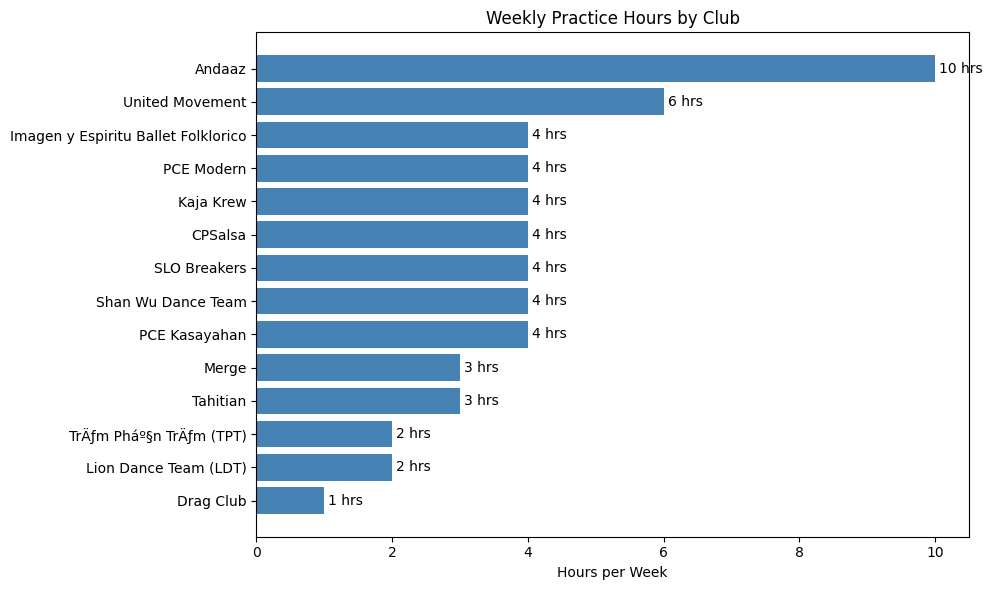

In [6]:
hours_df = clubs[['name', 'hours_per_week']].dropna().sort_values('hours_per_week', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(hours_df['name'], hours_df['hours_per_week'], color='steelblue')
ax.bar_label(bars, fmt='%.0f hrs', padding=3)
ax.set_xlabel('Hours per Week')
ax.set_title('Weekly Practice Hours by Club')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 5. Performances Per Year by Club

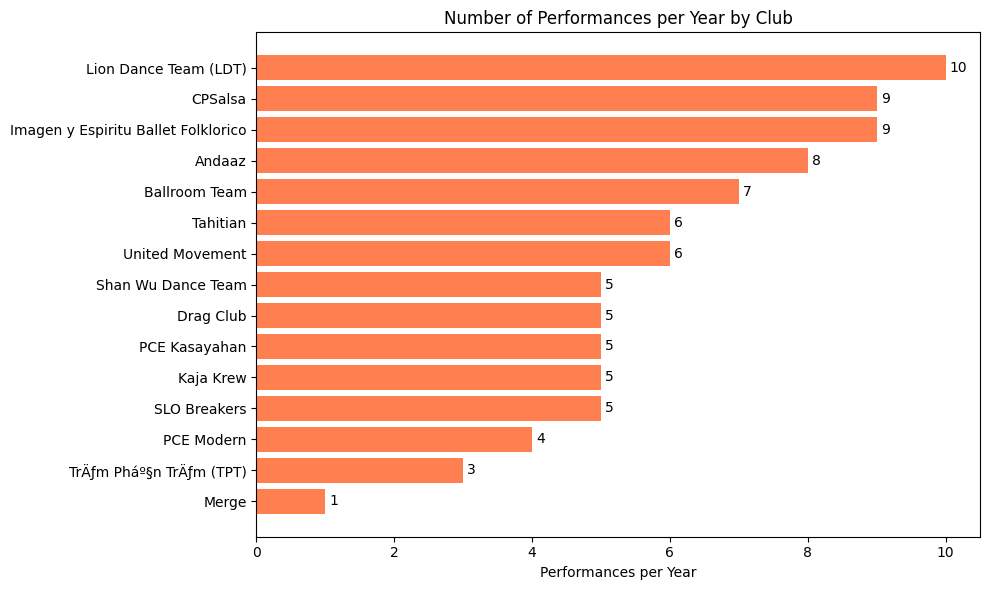

In [7]:
perf_df = clubs[['name', 'performances_per_year']].dropna().sort_values('performances_per_year', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(perf_df['name'], perf_df['performances_per_year'], color='coral')
ax.bar_label(bars, fmt='%.0f', padding=3)
ax.set_xlabel('Performances per Year')
ax.set_title('Number of Performances per Year by Club')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 6. Boolean Attribute Summary

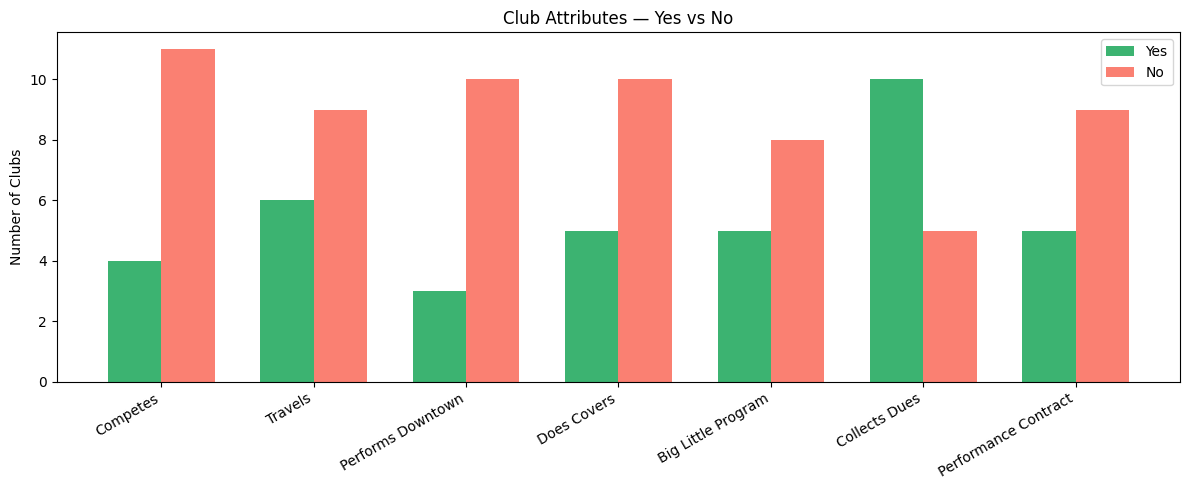

In [8]:
bool_cols = ['competes', 'travels', 'performs_downtown', 'does_covers',
             'big_little_program', 'collects_dues', 'performance_contract']

# Count True values per attribute (ignore nulls)
bool_counts = {col: clubs[col].dropna().sum() for col in bool_cols}
bool_totals = {col: clubs[col].dropna().count() for col in bool_cols}

labels = [c.replace('_', ' ').title() for c in bool_cols]
yes_vals = [bool_counts[c] for c in bool_cols]
no_vals  = [bool_totals[c] - bool_counts[c] for c in bool_cols]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x, yes_vals, width, label='Yes', color='mediumseagreen')
ax.bar([i + width for i in x], no_vals, width, label='No', color='salmon')
ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Number of Clubs')
ax.set_title('Club Attributes — Yes vs No')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()

## 7. Cultural Associations

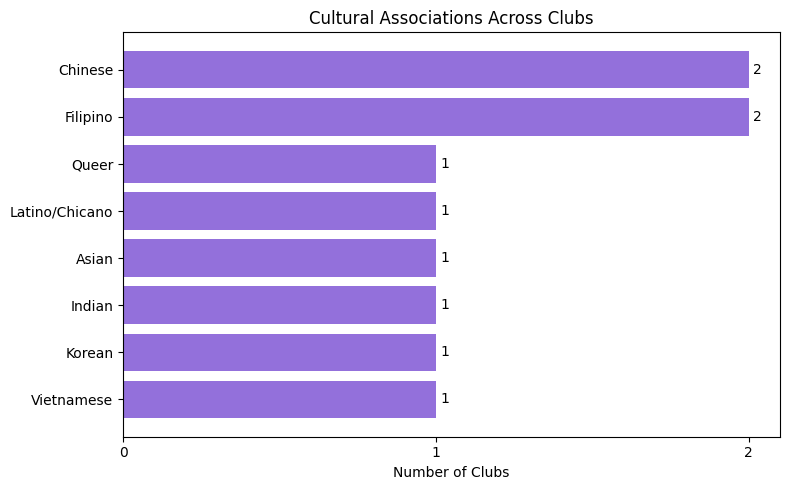

In [9]:
from collections import Counter

# Flatten the list-of-lists, skip nulls
all_cultures = []
for entry in clubs['cultural_association']:
    if isinstance(entry, list):
        all_cultures.extend(entry)

culture_counts = Counter(all_cultures)
culture_df = pd.DataFrame(culture_counts.items(), columns=['culture', 'count']).sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(culture_df['culture'], culture_df['count'], color='mediumpurple')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Clubs')
ax.set_title('Cultural Associations Across Clubs')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 8. Skill Levels Accepted

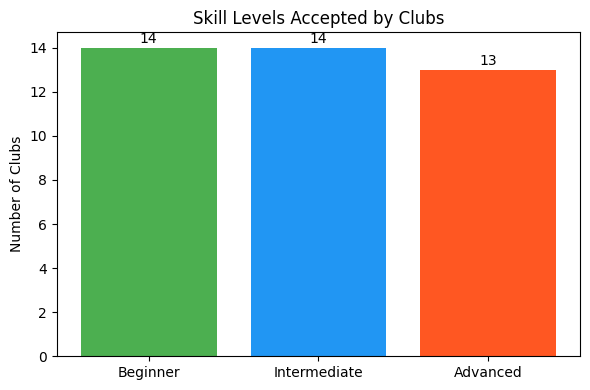

In [10]:
level_counts = {'Beginner': 0, 'Intermediate': 0, 'Advanced': 0}

for levels in clubs['skill_levels']:
    if isinstance(levels, list):
        for lvl in levels:
            if lvl in level_counts:
                level_counts[lvl] += 1

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(level_counts.keys(), level_counts.values(), color=['#4CAF50', '#2196F3', '#FF5722'])
ax.set_ylabel('Number of Clubs')
ax.set_title('Skill Levels Accepted by Clubs')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for i, (k, v) in enumerate(level_counts.items()):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 9. Dance Styles

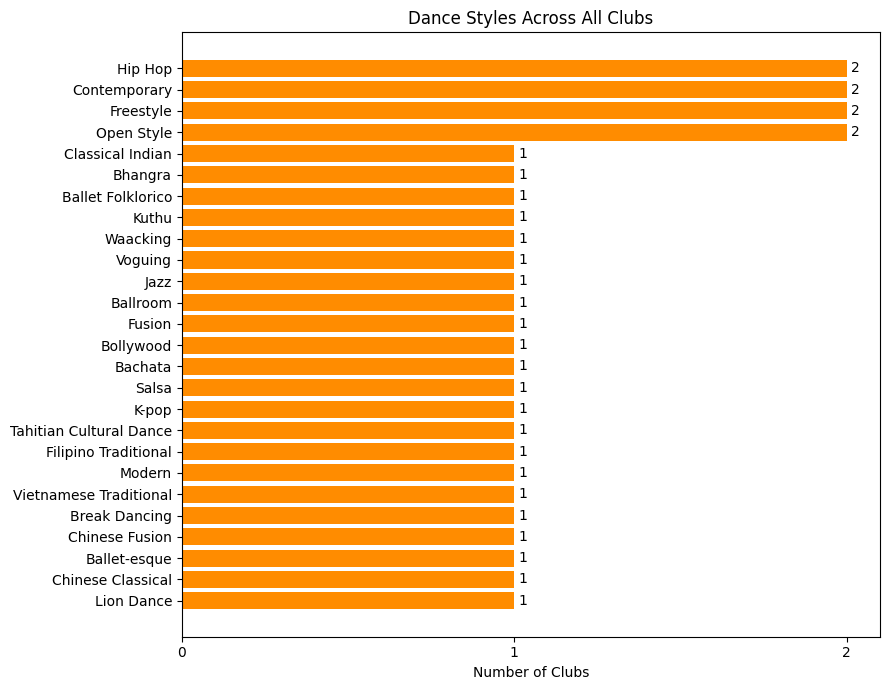

In [11]:
all_styles = []
for entry in clubs['dance_styles']:
    if isinstance(entry, list):
        all_styles.extend(entry)

style_counts = Counter(all_styles)
style_df = pd.DataFrame(style_counts.items(), columns=['style', 'count']).sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(style_df['style'], style_df['count'], color='darkorange')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Clubs')
ax.set_title('Dance Styles Across All Clubs')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 10. Quick Reference Table

In [12]:
def fmt_bool(val):
    if val is True:
        return '✓'
    elif val is False:
        return '✗'
    return '?'

summary = clubs[['name', 'hours_per_week', 'competes', 'travels',
                  'collects_dues', 'big_little_program', 'performances_per_year']].copy()

for col in ['competes', 'travels', 'collects_dues', 'big_little_program']:
    summary[col] = summary[col].apply(fmt_bool)

summary.columns = ['Club', 'Hrs/Wk', 'Competes', 'Travels', 'Dues', 'Big/Little', 'Perfs/Yr']
summary = summary.set_index('Club')
summary

,Hrs/Wk,Competes,Travels,Dues,Big/Little,Perfs/Yr
Club,,,,,,
Lion Dance Team (LDT),2.0,✗,✓,✗,✗,10
Shan Wu Dance Team,4.0,✗,✗,✗,✗,5
SLO Breakers,4.0,✓,✓,✓,✓,5
TrÄƒm Pháº§n TrÄƒm (TPT),2.0,✗,✗,✓,✗,3
PCE Kasayahan,4.0,✗,✗,✓,✗,5
PCE Modern,4.0,✗,✗,✓,✓,4
Kaja Krew,4.0,✗,✗,✓,✓,5
CPSalsa,4.0,✗,✓,✓,✗,9
Tahitian,3.0,✗,✗,✗,?,6
